# **GRADTDA 5620 Final Project**

## Pokemon Card Price Predictor

`Goal:` Create a pricing predictor for Pokemon card values

---



### **Exploratory Data Analysis**

In [2]:
# %pip install pandas matplotlib seaborn÷

import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# read in dataset
df = pd.read_csv('./pokemon_cards_ultimate_2026.csv')

display(df.head())
display(df.info())

,title,pokemon_name,set_name,card_number,rarity_class,language,category,condition_std,is_graded,grading_company,...,currency,price_usd,price_tier_usd,seller_country,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
0,Ceruledge ex SAR 203/187 SV8a Terastal Fest ex...,Ceruledge,SV8A,203/187,SAR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,20.99,Uncommon,United Kingdom,15,0,2,2.0,5.0,2026.0
1,Zacian V Holo SAR 225/172 S12a VSTAR Universe ...,Zacian,S12A,225/172,SAR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,15.17,Uncommon,United Kingdom,15,0,2,2.0,5.0,2026.0
2,Piplup AR 085/080 M2 Japanese Pokemon Card Jap...,Piplup,INFERNO X,085/080,AR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,3.96,Common,United Kingdom,15,0,2,2.0,5.0,2026.0
3,POKEMON Card Kyurem EX 25/98 XY Ancient Origin...,Kyurem,XY,25/98,Unknown,English,Single Cards,Near Mint,0,NaN,...,GBP,3.12,Common,United Kingdom,15,0,2,2.0,5.0,2026.0
4,Pokemon Card Vulpix AR 067/063 M1L Mega Brave ...,Vulpix,MEGA BRAVE,067/063,AR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,2.71,Common,United Kingdom,15,0,2,2.0,5.0,2026.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 542 non-null    object 
 1   pokemon_name          542 non-null    object 
 2   set_name              542 non-null    object 
 3   card_number           411 non-null    object 
 4   rarity_class          542 non-null    object 
 5   language              542 non-null    object 
 6   category              542 non-null    object 
 7   condition_std         542 non-null    object 
 8   is_graded             542 non-null    int64  
 9   grading_company       39 non-null     object 
 10  numeric_grade         30 non-null     float64
 11  is_holo               542 non-null    int64  
 12  is_full_art           542 non-null    int64  
 13  is_v_card             542 non-null    int64  
 14  is_ex_card            542 non-null    int64  
 15  is_gx_card            5

None

In [4]:
df.describe()

,is_graded,numeric_grade,is_holo,is_full_art,is_v_card,is_ex_card,is_gx_card,is_promo,is_shadowless,is_1st_edition,is_rainbow,is_gold,price,price_usd,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
count,542.000000,30.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,538.000000,538.0,538.0
mean,0.071956,9.600000,0.302583,0.049815,0.049815,0.166052,0.025830,0.086716,0.001845,0.049815,0.001845,0.005535,31.595166,39.830111,39.754613,0.236162,4.503690,3.730483,5.0,2026.0
std,0.258653,0.498273,0.459801,0.217765,0.217765,0.372471,0.158775,0.281678,0.042954,0.217765,0.042954,0.074260,124.768916,151.256000,42.454550,0.425115,3.864023,0.854302,0.0,0.0
min,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.360000,0.490000,1.000000,0.000000,2.000000,2.000000,5.0,2026.0
25%,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,2.032500,4.000000,0.000000,2.000000,3.000000,5.0,2026.0
50%,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.200000,5.340000,26.000000,0.000000,2.000000,4.000000,5.0,2026.0
75%,0.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.502500,15.160000,88.000000,0.000000,6.000000,4.000000,5.0,2026.0
max,1.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1475.000000,1591.410000,114.000000,1.000000,22.000000,5.000000,5.0,2026.0


In [5]:
df.describe(include='object')

,title,pokemon_name,set_name,card_number,rarity_class,language,category,condition_std,grading_company,currency,price_tier_usd,seller_country
count,542,542,542,411,542,542,542,542,39,542,542,542
unique,536,76,80,387,13,6,2,10,4,3,5,5
top,Emboar Holo 008/037 HS 2010 Vintage Rare Ninte...,Unknown,Unknown,045/184,Unknown,English,Single Cards,Near Mint,ACE,GBP,Common,United Kingdom
freq,2,317,338,2,336,326,534,397,21,369,222,369


In [7]:
# assign each col type
string_cols = ['title']

bool_cols = [
    'is_graded', 
    'is_holo', 
    'is_full_art', 
    'is_v_card', 
    'is_ex_card',
    'is_gx_card', 
    'is_promo',
    'is_shadowless', 
    'is_1st_edition',
    'is_rainbow', 
    'is_gold',
    'ships_worldwide'
]

nominal_categorical_cols = [
    'pokemon_name',
    'set_name',
    'language',
    'category',
    'grading_company',
    'currency',
    'seller_country'
]

ordinal_categorical_cols = [
    'card_number',
    'rarity_class',
    'condition_std',
    'price_tier_usd'
]

int_cols = [
    'numeric_grade',
    'price',
    'price_usd',
    'seller_listing_count',
    'image_count',
    'days_since_sold'
]

datetime_cols = [
    'sale_month',
    'sale_year'
]

df[string_cols] = df[string_cols].astype(str)
df[bool_cols] = df[bool_cols].astype(bool)
df[nominal_categorical_cols] = df[nominal_categorical_cols].astype('category')
df[ordinal_categorical_cols] = df[ordinal_categorical_cols].astype('category')


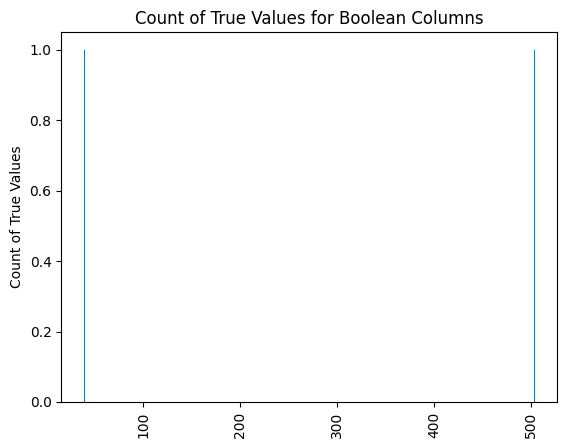

In [18]:
# initial data analysis
# plot the boolean variables
plt.bar(x = df['is_graded'].value_counts(), height=1)
plt.xticks(rotation=90)
plt.title('Count of True Values for Boolean Columns')
plt.ylabel('Count of True Values')
plt.show()

In [ ]:
# convert card number to a single digit and then add a col for set length?